In [3]:
import pandas as pd
df = pd.read_csv('banking_transactions.csv')

#Menampilkan semua daftar nama kolom
print("daftar kolom")
print(df.columns)

# Menampilkan 5 baris pertama
df.head()

#jumlah transaksi yang terindikasi penipuan dan transaksi yang normal
print(df.fraud_flag.value_counts())

#rata-rata transaksi penipuan dan non penipuan
avg_amount_transaction = df.groupby('fraud_flag')['transaction_amount'].mean()

print(avg_amount_transaction)

daftar kolom
Index(['transaction_id', 'transaction_amount', 'login_attempts',
       'device_risk_score', 'transfer_frequency', 'anomaly_score',
       'account_age_days', 'transaction_time_hour',
       'failed_transactions_last_30d', 'avg_monthly_balance',
       'daily_transaction_count', 'geo_distance_km',
       'session_duration_minutes', 'transaction_velocity_score',
       'payment_channel', 'authentication_type', 'card_present_flag',
       'international_transaction_flag', 'suspicious_ip_flag', 'fraud_flag'],
      dtype='object')
fraud_flag
False    8749
True     1251
Name: count, dtype: int64
fraud_flag
False    12398.003867
True     12515.910639
Name: transaction_amount, dtype: float64


In [4]:
#Skor Risiko Perangkat
avg_risk_device = df.groupby('fraud_flag')['device_risk_score'].mean()
print(avg_risk_device)

fraud_flag
False    50.271322
True     50.158353
Name: device_risk_score, dtype: float64


In [5]:
#transaksi gagal dalam 30 hari terakhir
avg_failed_trans = df.groupby('fraud_flag')['failed_transactions_last_30d'].mean()
print(avg_failed_trans)

fraud_flag
False    12.459024
True     12.289369
Name: failed_transactions_last_30d, dtype: float64


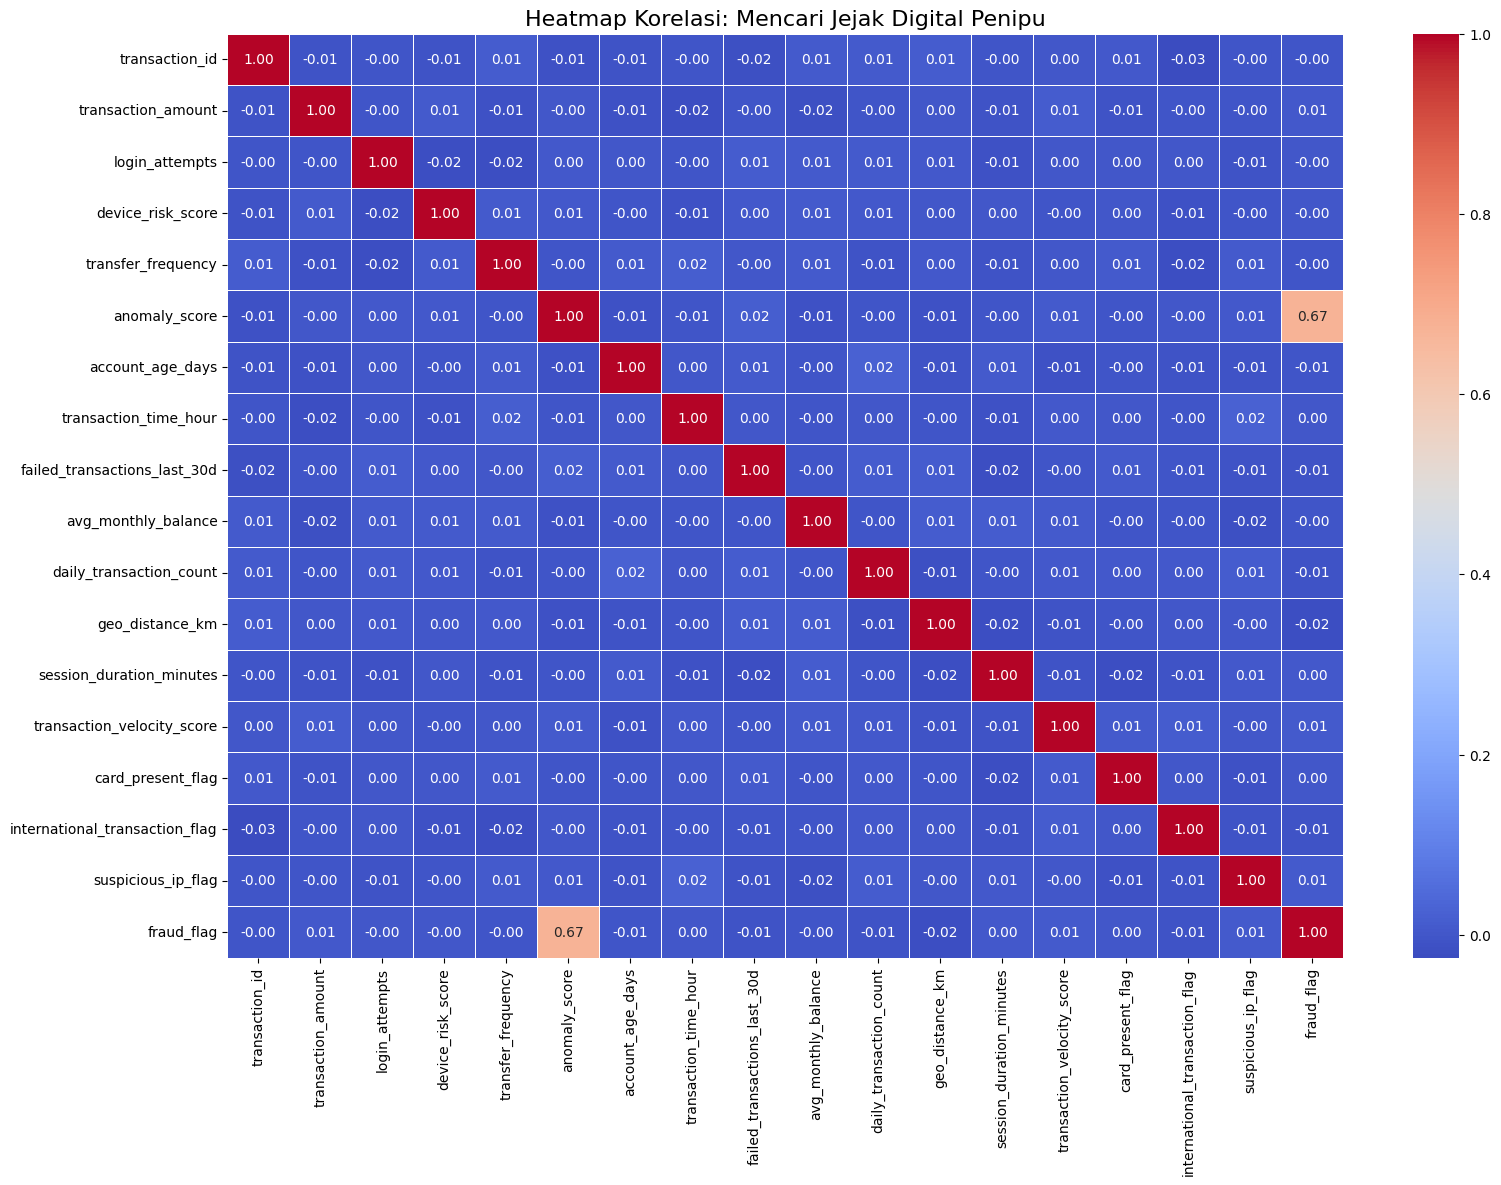

In [6]:
# Import library
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Kita hanya ambil kolom yang berisi angka/boolean untuk dihitung korelasinya
kolom_angka = df.select_dtypes(include=['number', 'bool'])
korelasi_data = kolom_angka.corr()

# 2. Mengatur ukuran kanvas gambar agar besar dan tidak saling tumpuk
plt.figure(figsize=(18, 12))

# 3. Merender Heatmap (Peta Panas)
sns.heatmap(korelasi_data,
            annot=True,         # Menampilkan angka di dalam kotak
            cmap='coolwarm',    # Tema warna (Merah untuk positif, Biru untuk negatif)
            fmt=".2f",          # Dibulatkan 2 angka di belakang koma
            linewidths=0.5)     # Memberi garis batas antar kotak

# 4. Memberikan judul dan memunculkan grafik
plt.title('Heatmap Korelasi: Mencari Jejak Digital Penipu', fontsize=16)
plt.show()

In [7]:
#anomali score rata rata
avg_anomali = df.groupby('fraud_flag')['anomaly_score'].mean()
print(avg_anomali)

fraud_flag
False    0.288470
True     0.771655
Name: anomaly_score, dtype: float64


In [8]:
# Import (Scikit-Learn)
from sklearn.model_selection import train_test_split

# 1. Menyiapkan Buku Pelajaran (X)
# Kita buang 'transaction_id' karena nomor urut tidak ada hubungannya dengan penipuan
# Kita buang 'fraud_flag' karena itu kunci jawabannya
X = df.drop(columns=['transaction_id', 'fraud_flag'])

# Mengubah semua kolom teks menjadi angka
X = pd.get_dummies(X, drop_first=True)

# 2. Menyiapkan Kunci Jawaban (y)
y = df['fraud_flag']

# 3. Membelah data (80% Belajar, 20% Ujian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah data untuk belajar (Train):", X_train.shape[0], "baris")
print("Jumlah data untuk ujian (Test)  :", X_test.shape[0], "baris")

Jumlah data untuk belajar (Train): 8000 baris
Jumlah data untuk ujian (Test)  : 2000 baris


In [9]:
# Import algoritma Pasukan Detektif (Random Forest)
from sklearn.ensemble import RandomForestClassifier

# 1. Menyiapkan Pasukan Detektif
# random_state=42 hanya agar hasil tebakan Anda
model_rf = RandomForestClassifier(random_state=42)

# 2. WAKTUNYA BELAJAR! (Training)
# Kita berikan Buku Pelajaran (X_train) dan Kunci Jawabannya (y_train)
print("Melatih model dengan 8000 data...")
model_rf.fit(X_train, y_train)
print("Proses training selesai! ")

# 3.(Predicting)
tebakan_ai = model_rf.predict(X_test)

print("AI telah selesai menebak 2000 transaksi !")

Melatih model dengan 8000 data...
Proses training selesai! 
AI telah selesai menebak 2000 transaksi !


Hasil deteksi :

              precision    recall  f1-score   support

       False       0.97      0.98      0.97      1750
        True       0.83      0.78      0.81       250

    accuracy                           0.95      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.95      0.95      0.95      2000



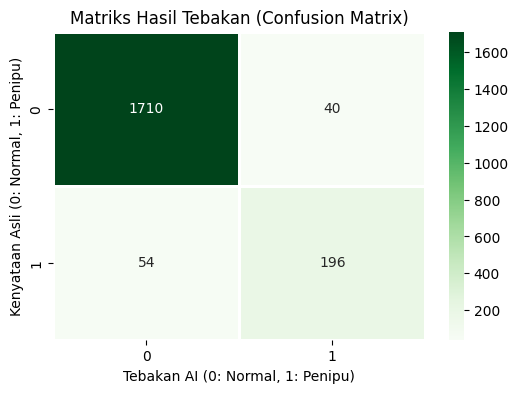

In [10]:
# Import alat penilai dari perpustakaan
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Menampilkan Rapor Rinci
print("Hasil deteksi :\n")
# Kita bandingkan Kunci Jawaban Asli (y_test) dengan Tebakan AI (tebakan_ai)
print(classification_report(y_test, tebakan_ai))

# 2. Membuat Grafik Matriks Evaluasi (Confusion Matrix)
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, tebakan_ai)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', linewidths=1)
plt.title('Matriks Hasil Tebakan (Confusion Matrix)')
plt.xlabel('Tebakan AI (0: Normal, 1: Penipu)')
plt.ylabel('Kenyataan Asli (0: Normal, 1: Penipu)')
plt.show()

/tmp/ipykernel_5167/1397521279.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tingkat_Kepentingan', y='Jejak_Digital', data=tabel_ranking.head(10), palette='magma')


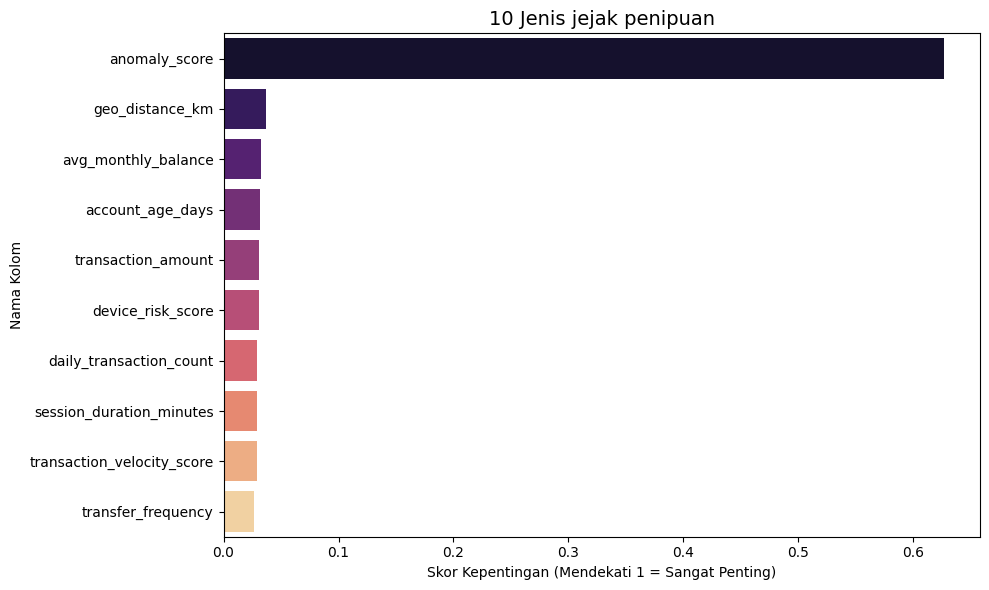

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengambil data ranking dari dalam model training
skor_penting = model_rf.feature_importances_
nama_kolom = X_train.columns

# 2. Membuat tabel ranking agar rapi dan mengurutkannya dari yang terbesar
tabel_ranking = pd.DataFrame({
    'Jejak_Digital': nama_kolom,
    'Tingkat_Kepentingan': skor_penting
}).sort_values(by='Tingkat_Kepentingan', ascending=False)

# 3. Menggambar grafik batang horizontal untuk Top 10 Jejak Digital
plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat_Kepentingan', y='Jejak_Digital', data=tabel_ranking.head(10), palette='magma')

plt.title('10 Jenis jejak penipuan', fontsize=14)
plt.xlabel('Skor Kepentingan (Mendekati 1 = Sangat Penting)')
plt.ylabel('Nama Kolom')
plt.tight_layout()
plt.show()

In [12]:
import joblib

# Menyimpan model_rf yang pertama ke dalam file
joblib.dump(model_rf, 'deteksi_fraud.pkl')

print("Model disimpan sebagai 'deteksi_fraud.pkl' ")

Model disimpan sebagai 'deteksi_fraud.pkl' 
